# Prediction Visualizations

This notebook loads the trained `unet_best.pth` from `outputs/`, runs the model on the test split, and visualizes masked input, ground-truth mask, and predicted mask side-by-side for several samples. Use the same `val_split` / `test_split` fractions as in `train.py` to reproduce the test split.

In [ ]:
# Imports
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from dataset import WaterDataset
from models import UNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [12]:
# Settings - adjust paths if needed
IMAGE_DIR = '../data/images'
MASK_DIR = '../data/masks'
OUTPUTS = Path('../outputs')
BEST_CHECKPOINT = OUTPUTS / 'unet_best.pth'
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
BATCH_SIZE = 4
print(BEST_CHECKPOINT)
print(BEST_CHECKPOINT.resolve())
print(BEST_CHECKPOINT.exists())

../outputs/unet_best.pth
/Users/markomarcetra/sattelite-water-unet/outputs/unet_best.pth
True


In [13]:
# Build dataset and test loader using same splits as training
dataset = WaterDataset(image_dir=IMAGE_DIR, mask_dir=MASK_DIR)
n = len(dataset)
test_size = max(1, int(n * TEST_SPLIT))
val_size = max(1, int(n * VAL_SPLIT))
train_size = n - val_size - test_size
_, _, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print('Test samples:', len(test_dataset))

Test samples: 15


In [14]:
# Load model and checkpoint
model = UNet(n_channels=3, n_classes=1).to(device)
print('BEST_CHECKPOINT ->', BEST_CHECKPOINT)
if BEST_CHECKPOINT.exists():
    cp = torch.load(BEST_CHECKPOINT, map_location=device)
    try:
        model.load_state_dict(cp)
        print('Loaded checkpoint:', BEST_CHECKPOINT)
    except Exception as e:
        print('load_state_dict failed:', repr(e))
else:
    print('Best checkpoint not found at', BEST_CHECKPOINT)

# weight-sum sanity check to ensure model parameters are not zeroed
total = 0.0
for p in model.parameters():
    total += p.abs().sum().item()
print('weight sum after load:', total)

model.eval()


BEST_CHECKPOINT -> ../outputs/unet_best.pth
Loaded checkpoint: ../outputs/unet_best.pth
weight sum after load: 150160.74824468582


UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

In [15]:
def visualize_batch(images, masks, preds, probs=None, ncols=4):
    # images: tensor (B, C, H, W) in [0,1] or similar
    # masks, preds: (B, 1, H, W) binary or prob
    B = images.shape[0]
    n = min(B, ncols)
    fig, axes = plt.subplots(3, n, figsize=(3*n, 9))
    for i in range(n):
        img = images[i].cpu().numpy().transpose(1,2,0)
        gt = masks[i].cpu().numpy().squeeze()
        pr = preds[i].cpu().numpy().squeeze()
        pb = probs[i].cpu().numpy().squeeze() if probs is not None else pr
        # clip or normalize image for display
        img = np.clip(img, 0, 1)
        # debug print per plotted sample (numpy values)
        try:
            print(f"Plotting sample {i}:", float(pb.min()), float(pb.max()), float(pb.mean()))
        except Exception:
            pass
        axes[0, i].imshow(img)
        # overlay predicted probabilities on top of the image for visibility
        axes[0, i].imshow(pb, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
        axes[0, i].axis('off')
        axes[0, i].set_title('masked input + pred overlay')
        axes[1, i].imshow(gt, cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')
        axes[1, i].set_title('ground truth')
        # show the probability heatmap for presentation (confidence map)
        im = axes[2, i].imshow(pb, cmap='viridis', vmin=0, vmax=1)
        axes[2, i].axis('off')
        axes[2, i].set_title('predicted probabilities')
        fig.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


probs min: 0.03452996164560318
probs max: 0.9765636920928955
probs mean: 0.5710304975509644
pred unique: [0. 1.]
pred sum: 204273

=== Per-sample diagnostics ===

Sample 0
probs: 0.05073649436235428 0.564859926700592 0.3919890522956848
pred sum: 40334 unique: [0. 1.]

Sample 1
probs: 0.3602791130542755 0.9765636920928955 0.9204742908477783
pred sum: 65536 unique: [1.]

Sample 2
probs: 0.10718242824077606 0.8529965877532959 0.6182032227516174
pred sum: 64088 unique: [0. 1.]

Sample 3
probs: 0.03452996164560318 0.684878408908844 0.3534555435180664
pred sum: 34315 unique: [0. 1.]
Plotting sample 0: 0.05073649436235428 0.564859926700592 0.3919890522956848
Plotting sample 1: 0.3602791130542755 0.9765636920928955 0.9204743504524231
Plotting sample 2: 0.10718242824077606 0.8529965877532959 0.6182032823562622
Plotting sample 3: 0.03452996164560318 0.684878408908844 0.3534555435180664


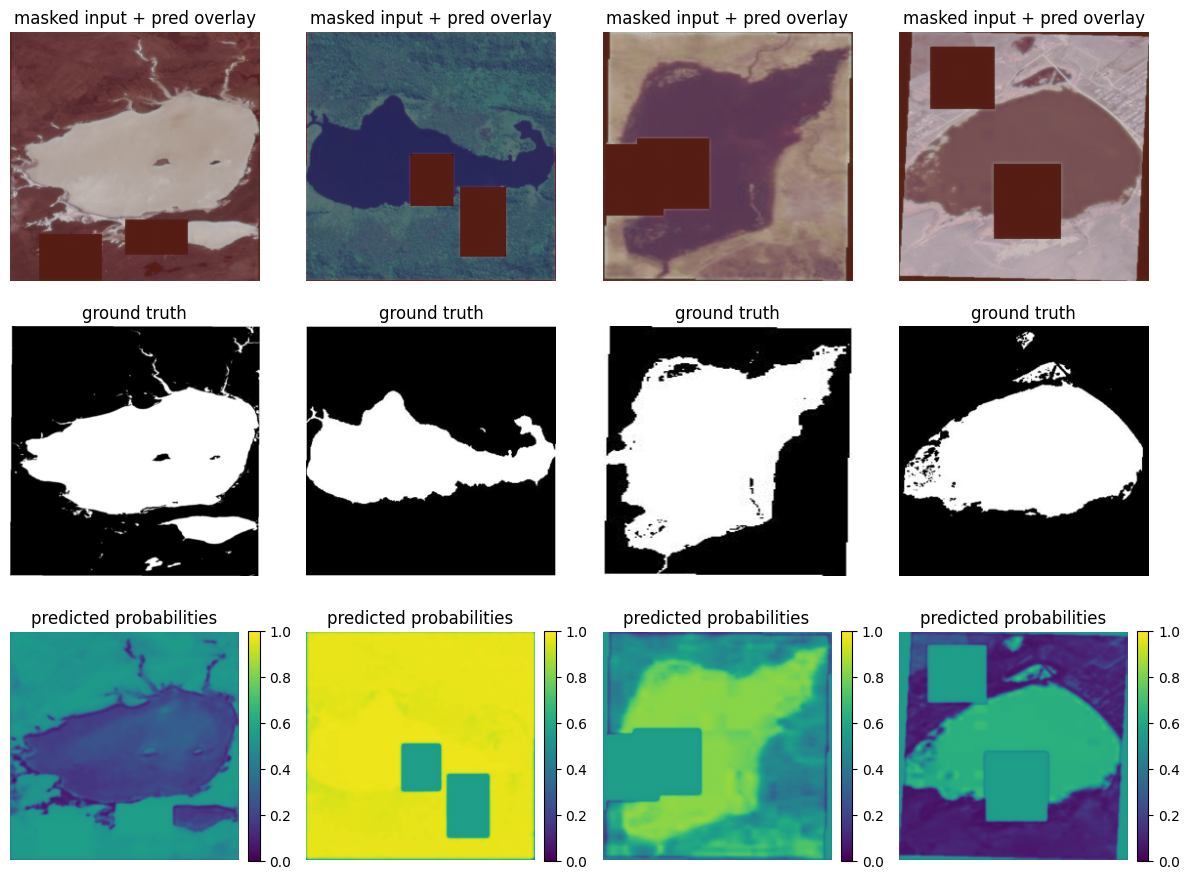

In [16]:
# Run a single batch and visualize (show probability maps and overlay)
with torch.no_grad():
    for batch in test_loader:
        # dataset is expected to return (orig, masked_image, mask) as in train.py
        _, masked_images, masks = batch
        masked_images = masked_images.to(device)
        logits = model(masked_images)
        probs = torch.sigmoid(logits)
        # lower threshold to 0.3 to check for low-confidence predictions
        preds = (probs > 0.3).float()
        # Diagnostic prints
        print('probs min:', float(probs.min().item()))
        print('probs max:', float(probs.max().item()))
        print('probs mean:', float(probs.mean().item()))
        print('pred unique:', preds.unique().cpu().numpy())
        print('pred sum:', int(preds.sum().item()))

        # Per-sample diagnostics to detect dud samples
        print("\n=== Per-sample diagnostics ===")
        for i in range(min(4, probs.shape[0])):
            print(f"\nSample {i}")
            print("probs:", float(probs[i].min().item()), float(probs[i].max().item()), float(probs[i].mean().item()))
            pred_i = (probs[i] > 0.3).float()
            print("pred sum:", int(pred_i.sum().item()), "unique:", pred_i.unique().cpu().numpy())

        # visualize probabilities and overlay (pass probs to visualize_batch)
        visualize_batch(masked_images, masks, preds, probs=probs, ncols=4)
        break


In [17]:
import os

print(os.getcwd())

/Users/markomarcetra/sattelite-water-unet/notebooks


In [18]:
import os

for root, dirs, files in os.walk(".."):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

../.venv/lib/python3.9/site-packages/__editable__.swu-0.1.0.pth
../.venv/lib/python3.9/site-packages/distutils-precedence.pth
../outputs/unet_epoch8.pth
../outputs/unet_epoch9.pth
../outputs/unet_best.pth
../outputs/unet_epoch14.pth
../outputs/unet_epoch15.pth
../outputs/unet_epoch11.pth
../outputs/unet_epoch10.pth
../outputs/unet_epoch12.pth
../outputs/unet_epoch13.pth
../outputs/unet_epoch2.pth
../outputs/unet_epoch3.pth
../outputs/unet_epoch1.pth
../outputs/unet_epoch4.pth
../outputs/unet_epoch5.pth
../outputs/unet_epoch7.pth
../outputs/unet_epoch6.pth


In [19]:
print(BEST_CHECKPOINT.exists())

True


In [20]:
from pathlib import Path

print("cwd:", Path.cwd())
print("checkpoint:", BEST_CHECKPOINT)
print("absolute:", BEST_CHECKPOINT.resolve())

cwd: /Users/markomarcetra/sattelite-water-unet/notebooks
checkpoint: ../outputs/unet_best.pth
absolute: /Users/markomarcetra/sattelite-water-unet/outputs/unet_best.pth


In [21]:
# Save high-resolution probability heatmaps for presentation
from pathlib import Path

save_dir = OUTPUTS / 'heatmaps'
save_dir.mkdir(parents=True, exist_ok=True)

with torch.no_grad():
    for batch in test_loader:
        _, masked_images, masks = batch
        masked_images = masked_images.to(device)
        logits = model(masked_images)
        probs = torch.sigmoid(logits)

        for i in range(min(4, probs.shape[0])):
            p = probs[i,0].cpu().numpy()
            fig, ax = plt.subplots(figsize=(12, 12), dpi=200)
            im = ax.imshow(p, cmap='viridis', vmin=0, vmax=1)
            ax.axis('off')
            ax.set_title(f'Predicted probability map (sample {i})')
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            out_path = save_dir / f'prob_map_sample_{i}.png'
            fig.savefig(out_path, bbox_inches='tight', pad_inches=0)
            plt.close(fig)

        break

print('Saved heatmaps to', save_dir.resolve())


Saved heatmaps to /Users/markomarcetra/sattelite-water-unet/outputs/heatmaps
